In [1]:
import tensorflow as tf, keras
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

I0000 00:00:1791545788.727752    1686 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791545789.210814    1686 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791545792.089775    1686 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0 | Keras 3.15.1


## 1. Imports and Configuration

This cell loads the libraries we use and sets the few values shared by the whole notebook:
where the files are, the size of the images, and the random seed.

In [3]:
print("[Block 1] Imports and configuration : starting...")

import hashlib, random, time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v3 as iio          # asked by the assignment: used to read information about the images
import tensorflow as tf
import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, f1_score)

# Fixed seed: the "random" choices (split, shuffling, starting weights) come out the same on every run.
# So when two models get different scores, it comes from the models, not from luck.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Where the files are. Paths are relative to the notebook folder.
# In the Docker container, this folder is /workspace (see docker-compose.yml).
# ROOT = Path("/workspace")
ROOT = Path("")
RAW = ROOT / "data_raw"      # original images, one folder per category. We only read them, we never change them
DATA = ROOT / "data"         # files we create (the image table data/index.csv). Safe to delete: it is rebuilt
RESULTS = ROOT / "results"   # trained models (.keras) and the results table (.csv)
LOGS = RESULTS / "logs"      # training logs for TensorBoard, one folder per model
RESULTS.mkdir(exist_ok=True)
LOGS.mkdir(exist_ok=True)

IMG_SIZE = (224, 224)   # every image is resized to 224 x 224 pixels, the size MobileNetV2 expects
BATCH = 32              # the model looks at the images in groups (batches) of 32

print("[Block 1] OK")

[Block 1] Imports and configuration : starting...
[Block 1] OK


## 2. The Data: one category per folder

TouNum's images come sorted in folders, one per category, in `data_raw/`: `Photo`, `Painting`,
`Schematics`, `Sketch` and `Text`.

**What the model learns:** to recognise the category of an image (5 possible answers).
The question of deliverable 1, *is it a photo or not?*, comes for free: an image is a photo when the
model answers `Photo`.

We put all the images in **one table** (a Pandas DataFrame), one row per image, with its category.
This table lets us:
- split the images into train / validation / test, with the same mix of categories in each part;
- train on some categories only if we want (for example the easy ones first);
- see after training **which categories the model mixes up**, and in particular which ones it takes for photos.

No file is copied or moved: `data_raw/` is only read. A folder name becomes a number (the label the
model learns) in one place only: the `CATEGORY_TO_LABEL` dictionary just below.

In [4]:
print("[Block 2a] Category -> label mapping : starting...")

# The model works with numbers, not words: each category gets a number from 0 to 4.
# This is the ONLY place where a folder name becomes a number.
# A folder that is not in this list is ignored, e.g. data_raw/Dataset/ (noisy images, for deliverable 2).
class_names = ["Painting", "Photo", "Schematics", "Sketch", "Text"]   # class_names[number] -> category name
CATEGORY_TO_LABEL = {name: i for i, name in enumerate(class_names)}  # category name -> number
NUM_CLASSES = len(class_names)
PHOTO = CATEGORY_TO_LABEL["Photo"]   # number of the Photo category: "is it a photo?" = "did the model answer PHOTO?"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}   # other files (e.g. desktop.ini) are skipped
MIN_SIDE = 32   # in pixels. Smaller "images" are tiny web icons or spacers (e.g. 2x2 black squares), not documents

print("[Block 2a] OK")

[Block 2a] Category -> label mapping : starting...
[Block 2a] OK


### 2.1 Image check: can we open every image?

Before training, we open **every image once** and write down what we see in a table
(one row per image):

| Column | In plain words |
|---|---|
| `path`, `category` | Where the image is, and which folder (Photo, Text…) it comes from |
| `readable` | Can we open it? |
| `width`, `height` | Its size in pixels |
| `mode` | Colour, black and white, with transparency… |
| `md5` | Its "fingerprint" |

Three important ideas:

1. **We open each image with the same tool as the training.** If TensorFlow can open it now, it will
   also open it during training. Without this check, one broken file could crash the training after
   two hours.
2. **The fingerprint (MD5) finds the duplicates.** It is a code computed from the content of the file:
   two identical files get the same code, even with different names. This matters because if the same
   image ends up both in the training images and in the test images, the model has already seen the
   answer, and the test score is wrong.
3. **The table is saved (cache).** Opening ~40,000 images takes a few minutes, so the table is saved in
   `data/index.csv`. Next time, the code reads this file instead, which is instant. If you add or change
   images in `data_raw/`, run `build_index(force=True)` to check everything again.

The next cell then removes the images that cause problems: the ones we cannot open, the tiny ones
(icons, not documents) and the copies.

In [6]:
print("[Block 2b] Image index : starting...")

def inspect_image(path):
    # Open one file and write down what the checks need: fingerprint, colour mode, size, can we open it?
    raw = path.read_bytes()
    info = {"md5": hashlib.md5(raw).hexdigest(), "mode": None,
            "width": None, "height": None, "readable": False}
    try:
        info["mode"] = iio.immeta(path).get("mode")   # L = grey, RGB = colour, RGBA = colour + transparency, P = palette, CMYK = print colours
        img = tf.io.decode_image(raw, channels=3, expand_animations=False)   # same opening tool as the training
        info["height"], info["width"] = int(img.shape[0]), int(img.shape[1])
        info["readable"] = True
    except Exception:
        pass   # the file is empty, cut off, or in a format TensorFlow cannot open: it stays readable = False
    return info

def build_index(force=False):
    # Build the table: one row per image of data_raw/, whatever its folder.
    # Folder names are turned into numbers later, so changing CATEGORY_TO_LABEL never needs a new scan.
    cache = DATA / "index.csv"
    if cache.exists() and not force:   # table already saved: read it instead of opening all the images again
        print(f"  index read from {cache}")
        return pd.read_csv(cache)
    rows = []
    for folder in sorted(p for p in RAW.iterdir() if p.is_dir()):
        files = sorted(f for f in folder.iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS)
        print(f"  {folder.name}/ : {len(files)} files, inspecting...")
        with ThreadPoolExecutor() as pool:   # opens several files at the same time, to go faster
            infos = list(pool.map(inspect_image, files))
        rows += [{"path": f.as_posix(), "category": folder.name, **i} for f, i in zip(files, infos)]
    index = pd.DataFrame(rows)
    DATA.mkdir(exist_ok=True)
    index.to_csv(cache, index=False)   # save the table for next time
    return index

index = build_index(force=True)
index["label"] = index["category"].map(CATEGORY_TO_LABEL)   # category -> number (empty for the folders not in the list)
print("  ignored folders (not in the mapping):", sorted(index.loc[index.label.isna(), "category"].unique()))
index = index[index.label.notna()].astype({"label": int})   # keep only the 5 categories
print(f"  {len(index)} images indexed")

print("[Block 2b] OK")

[Block 2b] Image index : starting...
  Dataset/ : 148 files, inspecting...


W0000 00:00:1791384621.431506    3505 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
I0000 00:00:1791384621.431845    3505 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13508 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


  Painting/ : 10000 files, inspecting...


W0000 00:00:1791384629.482908    3631 local_rendezvous.cc:412] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input size should match (header_size + row_size * abs_height) but they differ by 2
Corrupt JPEG data: 419 extraneous bytes before marker 0xd9
/usr/local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:760: UserWarning: Metadata Warning, tag 33723 had too many entries: 14, expected 1
  warnings.warn(
W0000 00:00:1791384638.748902    3633 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


  Photo/ : 9993 files, inspecting...
  Schematics/ : 10000 files, inspecting...
  Sketch/ : 1406 files, inspecting...
  Text/ : 10000 files, inspecting...
  ignored folders (not in the mapping): ['Dataset']
  41399 images indexed
[Block 2b] OK


In [8]:
print("[Block 2c] Quality check : starting...")

index["too_small"] = index[["width", "height"]].min(axis=1) < MIN_SIDE   # an icon or a spacer, not a real document
index["duplicate"] = index.duplicated("md5", keep="first")   # same fingerprint as an earlier image: it is a copy

# Summary per category: number of images, number of problems, typical size
quality = index.groupby("category").agg(
    images=("path", "size"),
    unreadable=("readable", lambda s: (~s).sum()),
    too_small=("too_small", "sum"),
    exact_duplicates=("duplicate", "sum"),
    median_width=("width", "median"),
    median_height=("height", "median"),
)
modes = pd.crosstab(index["category"], index["mode"].fillna("?"))   # number of images per colour mode, per category
display(quality.join(modes))

# The same file in two different categories would mean that one of its two labels is wrong
per_md5 = index.groupby("md5")["category"].nunique()
print("  identical files found in several categories:", int((per_md5 > 1).sum()))
print("  unreadable files:", index.loc[~index.readable, "path"].tolist())

# Cleaning: remove the images we cannot open, the too small ones and the copies.
# `index` keeps every row (to see what was removed), `df` is the clean table used from now on
df = index[index.readable & ~index.too_small & ~index.duplicate].copy()
print(f"  {len(index)} -> {len(df)} images after cleaning")

print("[Block 2c] OK")

[Block 2c] Quality check : starting...


,images,unreadable,too_small,exact_duplicates,median_width,median_height,CMYK,L,P,RGB,RGBA
category,,,,,,,,,,,
Painting,10000,1,0,4,800.0,800.0,1,82,5,9907,5
Photo,9993,0,0,0,640.0,480.0,0,25,0,9968,0
Schematics,10000,0,662,691,672.0,462.0,0,116,0,9884,0
Sketch,1406,0,0,0,1111.0,1111.0,0,868,0,538,0
Text,10000,0,0,1,595.0,842.0,0,0,0,10000,0


  identical files found in several categories: 0
  unreadable files: ['data_raw/Painting/painting_02662.jpg']
  41399 -> 40301 images after cleaning
[Block 2c] OK


### 2.2 Splitting the images: train / validation / test

We cut the clean images into three parts:
- **train (70 %)**: the images the model learns from;
- **validation (15 %)**: images used *during* training to check that the model really learns,
  and does not just learn the training images by heart;
- **test (15 %)**: images kept aside until the very end, to give the final score. The model never
  learns from them.

Each part gets **the same mix of categories** (same share of photos, paintings, texts…). This is called
a *stratified* split.

The split is done **once**, before anything is learned from the data. The copies were removed just before,
so the same image cannot be both in train and in test. That would be cheating: the model would already
know the answer (this is called *data leakage*). The seed is fixed, so the split is the same on every computer.

In [9]:
print("[Block 2d] Split : starting...")

# First cut: 70 % train, 30 % rest. Then the rest is cut in two halves: 15 % validation, 15 % test.
# stratify=category: each part keeps the same share of each category
train_part, rest = train_test_split(df, test_size=0.30, stratify=df["category"], random_state=SEED)
val_part, test_part = train_test_split(rest, test_size=0.50, stratify=rest["category"], random_state=SEED)
df["split"] = "train"   # write in the table which part each image goes to
df.loc[val_part.index, "split"] = "val"
df.loc[test_part.index, "split"] = "test"

# Safety check: the same image (same fingerprint) must never be in two parts
assert df.groupby("md5")["split"].nunique().max() == 1, "the same image is in two splits"

# Number of images per category in each part, then 5 random rows of the table
counts = pd.crosstab(df["category"], df["split"], margins=True, margins_name="total")[["train", "val", "test", "total"]]
display(counts)
display(df.sample(5, random_state=SEED)[["path", "category", "label", "split"]])

print("[Block 2d] OK")

[Block 2d] Split : starting...


split,train,val,test,total
category,,,,
Painting,6996,1499,1500,9995
Photo,6995,1499,1499,9993
Schematics,6236,1336,1336,8908
Sketch,984,211,211,1406
Text,6999,1500,1500,9999
total,28210,6045,6046,40301


,path,category,label,split
6109,data_raw/Painting/painting_05962.jpg,Painting,0,val
38737,data_raw/Text/text_07191.jpg,Text,4,test
1631,data_raw/Painting/painting_01484.jpg,Painting,0,train
20655,data_raw/Schematics/schematics_00515.jpg,Schematics,2,train
38211,data_raw/Text/text_06665.jpg,Text,4,train


[Block 2d] OK


[Block 2e] Distribution + class imbalance : starting...


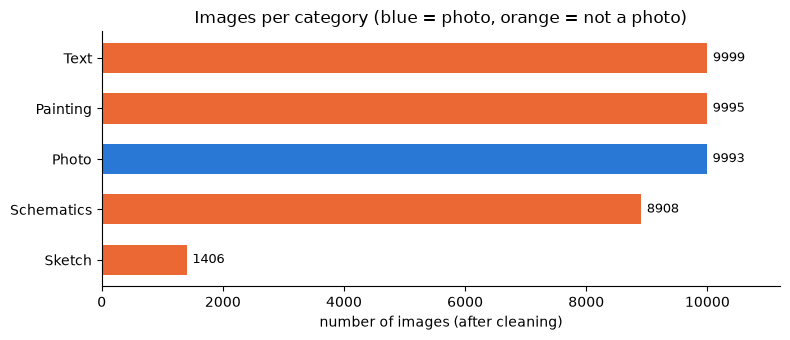

  share of each category (train): {'Painting': 0.248, 'Photo': 0.248, 'Schematics': 0.221, 'Sketch': 0.035, 'Text': 0.248}
  class_weight: {'Painting': 0.806, 'Photo': 0.807, 'Schematics': 0.905, 'Sketch': 5.734, 'Text': 0.806}
[Block 2e] OK


In [10]:
print("[Block 2e] Distribution + class imbalance : starting...")

# Bar chart: number of images per category (photos in blue, the rest in orange)
per_cat = df["category"].value_counts().sort_values()
colors = ["#2a78d6" if CATEGORY_TO_LABEL[c] == PHOTO else "#eb6834" for c in per_cat.index]
fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(per_cat.index, per_cat.values, color=colors, height=0.6)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel("number of images (after cleaning)")
ax.set_title("Images per category (blue = photo, orange = not a photo)")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, per_cat.max() * 1.12)
plt.tight_layout()
plt.show()

# Sketch is rare: only ~4 % of the training images. Without a fix, the model could almost ignore the
# sketches and still get a good score. Class weights fix this: a mistake on a rare category costs more,
# so that in total each category counts as much as the others. Computed on the training images only.
train_labels = df.loc[df.split == "train", "label"]
weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=train_labels)
class_weight = dict(enumerate(map(float, weights)))   # {category number: weight}
shares = train_labels.value_counts(normalize=True).sort_index()   # share of each category in train
print("  share of each category (train):", {class_names[k]: round(v, 3) for k, v in shares.items()})
print("  class_weight:", {class_names[k]: round(v, 3) for k, v in class_weight.items()})

print("[Block 2e] OK")

## 3. Loading the Images (tf.data)

Our table only holds the **paths** of the images, not the images themselves. `tf.data` opens the
images **while the model trains**, one small group (batch) at a time. So the ~38,000 images never
have to fit in memory all at once.

Here the pixels keep their values from 0 to 255. Turning them into the range a model expects is done
**inside each model** (`Rescaling(1/255)` for the MLP and the CNN, `preprocess_input` for MobileNetV2).
It is a fixed formula, not something learned from our images, so no information can leak from the test
images. And because it is saved inside the model, new images in production get exactly the same treatment.

`make_dataset(split, categories)` can keep only some categories, for example to train on the easy ones
first. The test set always contains every category.

In [11]:
print("[Block 3] Loading the images : starting...")

AUTOTUNE = tf.data.AUTOTUNE   # let TensorFlow choose how many images to prepare at the same time

def load_image(path, label):
    # Open one image from its path and resize it, so that all the images have the same size
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    # channels=3: grey, transparent, palette and print-colour images all become normal colour (RGB) images
    img.set_shape([None, None, 3])        # tells TensorFlow "this is a colour image": resize needs to know it
    img = tf.image.resize(img, IMG_SIZE)  # 224 x 224, pixels from 0 to 255. Images are stretched, not cropped
    return img, label

def make_dataset(split, categories=None, shuffle=False):
    # Build the stream of (image, label) pairs for one part: "train", "val" or "test"
    part = df[df["split"] == split]
    if categories is not None:   # optional: keep only some categories
        part = part[part["category"].isin(categories)]
    labels = part["label"].to_numpy("int32")   # one number per image: its category (0 to 4)
    ds = tf.data.Dataset.from_tensor_slices((part["path"].to_numpy(), labels))
    if shuffle:   # mix the order at every epoch. We mix the paths, not the images, so it costs nothing
        ds = ds.shuffle(len(part), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)   # open the images, several at a time
    return ds.batch(BATCH).prefetch(AUTOTUNE)   # groups of 32. prefetch: the next group is prepared while the model works on this one

# None = all the categories. Example to start with the easy ones: ["Photo", "Text", "Schematics"]
TRAIN_CATEGORIES = None
train_ds = make_dataset("train", TRAIN_CATEGORIES, shuffle=True)
val_ds = make_dataset("val", TRAIN_CATEGORIES)
test_ds = make_dataset("test")   # never mixed: prediction number i is for row i of test_df
test_df = df[df["split"] == "test"]

# Quick check on one group: size of the images, pixel values, number of images of each category
for images, labels in train_ds.take(1):
    print("  images:", images.shape, images.dtype, "| min", float(tf.reduce_min(images)), "max", float(tf.reduce_max(images)))
    print("  labels:", labels.shape, labels.dtype, "| images per class in this batch:",
          np.bincount(labels.numpy(), minlength=NUM_CLASSES).tolist())

print("[Block 3] OK")

[Block 3] Loading the images : starting...
  images: (32, 224, 224, 3) <dtype: 'float32'> | min 0.0 max 255.0
  labels: (32,) <dtype: 'int32'> | images per class in this batch: [7, 8, 6, 1, 10]
[Block 3] OK


W0000 00:00:1791384770.695589    2019 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


## 4. Visual Inspection of the Data

Before training, we look at a few images with their label. It is the fastest way to catch a loading
bug, a wrong label or a broken image.

W0000 00:00:1791384770.808852    2019 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554432 bytes after encountering the first element of size 33554432 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


[Block 4] Visual inspection : starting...
[Block 4] OK


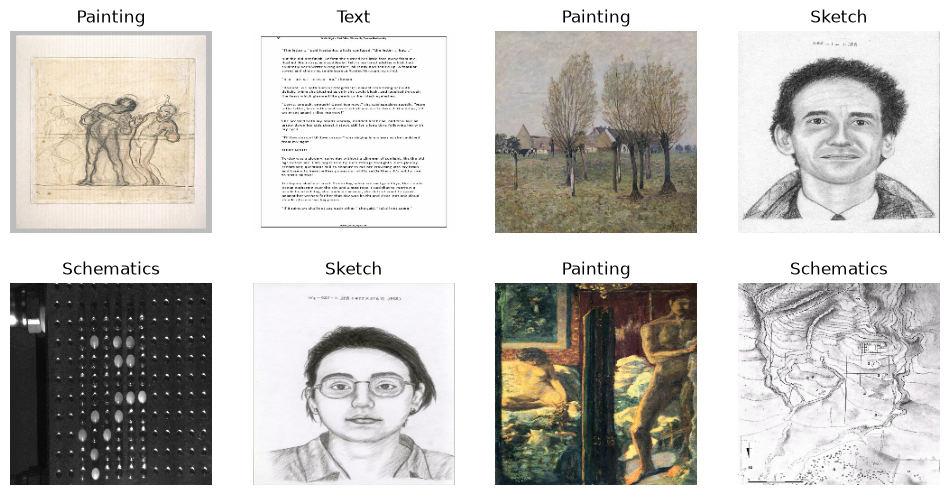

In [12]:
print("[Block 4] Visual inspection : starting...")

# Always look at the data before training: it catches loading bugs, wrong labels
# or broken images early.
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):   # take one group of 32 training images
    for i in range(8):   # and show the first 8
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))   # back to whole numbers from 0 to 255, so matplotlib can draw it
        plt.title(class_names[int(labels[i])])           # number -> category name
        plt.axis("off")

print("[Block 4] OK")

## 5. Data Augmentation (against overfitting)

*Overfitting* is when the model learns the training images by heart, instead of learning what makes a
photo a photo. It then does well on the images it has already seen, and badly on new ones.

To make this harder, we change each training image a little, at random (mirror, small rotation, small
zoom), every time the model sees it. So the model never sees exactly the same image twice.

In [13]:
print("[Block 5] Data augmentation : starting...")

# Small random changes, only during training: Keras turns them off by itself for validation, test and predictions.
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),   # mirror left-right (a mirrored photo is still a photo)
    layers.RandomRotation(0.1),        # turn by up to 10 % of a full turn (about 36 degrees)
    layers.RandomZoom(0.1),            # zoom in or out by up to 10 %
])

print("[Block 5] OK")

[Block 5] Data augmentation : starting...
[Block 5] OK


## 6. Building the Architectures to Compare

We build four models, from the simplest to the most advanced. They all get the same images, the same
training and the same evaluation: only the model changes, so the comparison is fair.

1. **MLP**: a basic network that sees the image as one long list of numbers. Reference point.
2. **CNN from scratch**: a network made for images, that we train entirely ourselves.
3. **Transfer learning**: we reuse MobileNetV2, a network already trained on more than a million images,
   and only train its last layer.
4. **Hybrid**: MobileNetV2 + a small CNN of our own on top. This is the one we keep as our final choice.

The goal is to compare their *bias / variance* trade-off: does the model learn too little (bias), or does
it learn the training images by heart (variance)?

In [14]:
# TOOL FOR VISUALIZING THE MODEL ARCHITECTURE
def draw_architecture(model):
    # Architecture diagram: one box per layer, with its output shape and its number of parameters
    model_layers = [c for c in model.layers if not isinstance(c, layers.InputLayer)]
    n = len(model_layers)
    fig, ax = plt.subplots(figsize=(8, 0.75 * (n + 1)))
    ax.set_xlim(0, 10); ax.set_ylim(0, n + 1); ax.axis("off")
    ax.text(5, n + 0.5, f"INPUT ({image_h}, {image_w}, 3)", ha="center", va="center", bbox=dict(boxstyle="round", fc="white"))
    for i, c in enumerate(model_layers):
        y = n - i - 0.5
        detail = f" - {c.filters} filters" if isinstance(c, layers.Conv2D) else (f" - {c.units} neurons" if isinstance(c, layers.Dense) else "")
        try:
            shape = str(tuple(c.output.shape[1:]))
        except Exception:
            shape = ""
        ax.text(5, y, f"{type(c).name}{detail}\n{shape}  {c.count_params():,} parameters", ha="center", va="center",
                fontsize=9, bbox=dict(boxstyle="round", fc="#cfe2f3"))
        ax.annotate("", xy=(5, y + 0.38), xytext=(5, y + 0.62), arrowprops=dict(arrowstyle="->"))
    ax.set_title(f"Architecture: {model.name} ({model.count_params():,} parameters)", fontweight="bold")
    plt.show()

### 6.0 MLP — the simplest network (reference point)

The MLP does not know that it is looking at an image. It flattens the picture into one long list of
224 × 224 × 3 = 150,528 numbers. So it no longer knows which pixels are next to each other, and a shape
learned in one corner of the image must be learned again in every other place.

Its first layer needs one weight per pixel and per neuron: about **19 million weights**, which know nothing
about images. With so many weights, the model can easily learn the training images by heart (overfitting).
This model is here to show that, not to be used.

**One change compared with a textbook MLP:** a `BatchNormalization` layer after the first layer. The
150,528 inputs are all positive, so at each training step all the weights move in the same direction and
the sums inside the neurons jump by tens of units. Without this layer, the first version of our MLP went
off the rails (loss ≈ 40 after 9 batches) and ended up giving the same answer for every image.
BatchNormalization brings these sums back to a normal size at each step.

In [15]:
print("[Block 6.0] MLP : definition...")

def build_mlp(name="MLP_baseline"):
    inputs = keras.Input(shape=IMG_SIZE + (3,))   # a 224 x 224 colour image
    x = augment(inputs)                     # same random mirror / rotation / zoom as the other models
    x = layers.Rescaling(1. / 255)(x)        # pixels 0-255 -> 0-1
    x = layers.Flatten()(x)                  # image -> one long list of 150,528 numbers: which pixel is next to which is lost
    x = layers.Dense(128)(x)                 # 128 neurons, each one linked to every pixel: ~19.3 million weights
    x = layers.BatchNormalization()(x)       # brings the 128 sums back to a normal size (see above). Without it, the MLP breaks
    x = layers.Activation("relu")(x)         # relu: keeps the positive values, replaces the negative ones by 0
    x = layers.Dropout(0.5)(x)               # switches off half of the neurons at random during training, against learning by heart
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)   # 5 numbers: the probability of each category (they add up to 1)

    model = keras.Model(inputs, outputs, name=name)
    # loss: a number that says how wrong the answers are. The model learns by making it smaller.
    # Adam: the method that adjusts the weights. 1e-3 = size of each adjustment step
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=keras.optimizers.Adam(1e-3),
                  metrics=["accuracy"])   # accuracy: share of images that get the right category
    return model

build_mlp().summary()   # show the architecture in text form
print("[Block 6.0] OK")

[Block 6.0] MLP : definition...


Model: "MLP_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    19,267,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,276,805 (73.54 MB)

 Trainable params: 19,276,549 (73.53 MB)

 Non-trainable params: 256 (1.00 KB)

[Block 6.0] OK


### 6.1 CNN from scratch (baseline)

A CNN (convolutional network) is made for images. It slides small 3 × 3 filters over the picture to
find simple shapes (edges, lines, textures), then combines them into bigger shapes. The same filter is
used everywhere in the image, so a shape learned in one corner is recognised everywhere. "From scratch"
means that all its weights start at random and are learned only from our images.

**Padding** controls what happens at the image border during a convolution. With `valid`, no extra pixels
are added, so a 3 × 3 filter cannot be centred on the outermost border and each dimension shrinks by 2.
With `same`, zeros are added around the image so the output keeps the same height and width (for stride 1).
This can preserve edge information, but the larger feature maps can cost more memory and computation; it
does not automatically improve accuracy. The next experiment changes only this parameter and compares
both choices on the same training/validation data. Validation results, not test results, are used here so
the test set remains untouched for the final evaluation.

In [16]:
print("[Block 6.1] CNN from scratch : definition...")

def build_cnn_from_scratch(name="CNN_from_scratch", padding="same"):
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = augment(inputs)                     # random mirror / rotation / zoom, during training only
    x = layers.Rescaling(1. / 255)(x)        # pixels 0-255 -> 0-1. This model learns from the raw pixels
    x = layers.Conv2D(32, (3, 3), activation="relu", padding=padding)(x)   # 32 filters of 3 x 3 pixels: find simple shapes (edges, lines)
    x = layers.MaxPooling2D((2, 2))(x)       # keeps the strongest value of each 2 x 2 square: the image becomes 2 times smaller
    x = layers.Dropout(0.25)(x)              # switches off 25 % of the values at random, against learning by heart
    x = layers.Conv2D(64, (3, 3), activation="relu", padding=padding)(x)   # 64 filters: combine the simple shapes into bigger ones
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Flatten()(x)                  # the grid of shapes found -> one long list of numbers
    x = layers.Dense(64, activation="relu")(x)   # 64 neurons that put everything together to take the decision
    x = layers.Dropout(0.5)(x)               # switches off half of the neurons at random, against learning by heart
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)   # the probability of each category

    model = keras.Model(inputs, outputs, name=name)
    model.compile(loss="sparse_categorical_crossentropy",   # same loss, optimizer and score as the other models
                  optimizer=keras.optimizers.Adam(1e-3),
                  metrics=["accuracy"])
    return model

build_cnn_from_scratch().summary()   # show the architecture in text form
print("[Block 6.1] OK")


[Block 6.1] CNN from scratch : definition...


Model: "CNN_from_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │    12,845,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,864,837 (49.08 MB)

 Trainable params: 12,864,837 (49.08 MB)

 Non-trainable params: 0 (0.00 B)

[Block 6.1] OK


#### Padding experiment: `valid` vs `same`

Run this cell after the data section and the CNN definition above. It trains two otherwise identical CNNs for
`PADDING_EPOCHS` epochs and reports the best validation accuracy and elapsed training time. The `valid`
model loses border pixels at each convolution; `same` pads with zeros to keep the feature-map size. The
train/validation sets, class weights, optimizer and network are kept the same. This is an experiment, not
a guarantee that `same` is better: compare validation accuracy **and** time/memory use. The `Flatten`
followed by `Dense` can also have more parameters with `same`, which the table reports. The test set is
not used, and neither model overwrites the main `CNN_from_scratch` checkpoint.

In [17]:
# print("[Padding experiment] valid vs same : starting...")

# PADDING_EPOCHS = 5   # reduce for a quick trial; increase for a more stable comparison
# padding_results = []

# for padding in ("valid", "same"):
#     tf.keras.utils.set_random_seed(SEED)   # make the initial weights comparable between the two trials
#     model = build_cnn_from_scratch(name=f"CNN_padding_{padding}", padding=padding)
#     conv_shapes = " -> ".join(
#         f"{layer.output.shape[1]}x{layer.output.shape[2]}"
#         for layer in model.layers if isinstance(layer, layers.Conv2D)
#     )
#     early_stop = keras.callbacks.EarlyStopping(
#         monitor="val_loss", patience=4, restore_best_weights=True
#     )
#     start = time.perf_counter()
#     history = model.fit(
#         make_dataset("train", TRAIN_CATEGORIES, shuffle=True),
#         validation_data=make_dataset("val", TRAIN_CATEGORIES),
#         epochs=PADDING_EPOCHS,
#         class_weight=class_weight,
#         callbacks=[early_stop],
#         verbose=1,
#     )
#     elapsed = time.perf_counter() - start
#     best_epoch = int(np.argmin(history.history["val_loss"]))
#     padding_results.append({
#         "padding": padding,
#         "conv output sizes": conv_shapes,
#         "parameters": model.count_params(),
#         "epochs": len(history.history["loss"]),
#         "best val accuracy": history.history["val_accuracy"][best_epoch],
#         "training seconds": round(elapsed, 1),
#         "seconds per epoch": round(elapsed / len(history.history["loss"]), 1),
#     })

# display(pd.DataFrame(padding_results).set_index("padding"))
# print("[Padding experiment] Conv2D kernel sizes stay fixed; downstream Dense parameters may change.")

### 6.2 Pure transfer learning (MobileNetV2 + GlobalAveragePooling)

Instead of learning to see from zero, we reuse **MobileNetV2**, a network already trained on more than
a million images (ImageNet). It already knows how to find edges, textures and objects. We **freeze** it
(training does not change its weights), and we only train one small last layer that turns what
MobileNetV2 sees into our 5 categories. There are few weights to learn, so it learns fast.

In [18]:
print("[Block 6.2] Pure transfer learning : definition...")

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def build_transfer_model(name="MobileNetV2_transfer"):
    # MobileNetV2 already trained on ImageNet, without its own last layer (include_top=False): we add ours
    base = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
    base.trainable = False   # frozen: training never changes its weights

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = augment(inputs)
    x = preprocess_input(x)          # pixels -> the range MobileNetV2 was trained with (-1 to 1), instead of Rescaling(1/255)
    x = base(x, training=False)      # MobileNetV2 describes the image as a 7 x 7 grid of 1280 numbers
    x = layers.GlobalAveragePooling2D()(x)   # average over the grid: one list of 1280 numbers per image
    x = layers.Dropout(0.2)(x)       # switches off 20 % of the values at random, against learning by heart
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)   # the only layer we train: 1280 numbers -> 5 probabilities

    model = keras.Model(inputs, outputs, name=name)
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=keras.optimizers.Adam(1e-3),
                  metrics=["accuracy"])
    return model

build_transfer_model().summary()   # show the architecture in text form
print("[Block 6.2] OK")

[Block 6.2] Pure transfer learning : definition...


Model: "MobileNetV2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

[Block 6.2] OK


### 6.3 Hybrid — MobileNetV2 (frozen) + our own CNN — final architecture

Same start as 6.2: the frozen MobileNetV2 describes the image. But instead of a single last layer, we put
**a small CNN of our own** on top, that we design and train ourselves. It can learn combinations that the
single layer of 6.2 cannot, and each of its layers can be explained.

In [19]:
print("[Block 6.3] Hybrid model : definition...")

def build_hybrid_model(name="Hybrid_MobileNetV2"):
    base = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
    base.trainable = False   # frozen, like in 6.2

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = augment(inputs)
    x = preprocess_input(x)           # pixels -> the range MobileNetV2 expects (-1 to 1)
    x = base(x, training=False)       # MobileNetV2 describes the image as a 7 x 7 grid of 1280 numbers
    # Our own small CNN on top of this description. 1 or 2 blocks at most: the 7 x 7 grid is already small
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)   # 64 filters that look for patterns in the grid
    x = layers.MaxPooling2D((2, 2))(x)   # grid 7 x 7 -> 3 x 3
    x = layers.Flatten()(x)              # grid -> one list of numbers
    x = layers.Dense(32, activation="relu")(x)   # 32 neurons that put everything together to take the decision
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)   # the probability of each category

    model = keras.Model(inputs, outputs, name=name)
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=keras.optimizers.Adam(1e-3),
                  metrics=["accuracy"])
    return model

build_hybrid_model().summary()   # show the architecture in text form
print("[Block 6.3] OK")

[Block 6.3] Hybrid model : definition...


Model: "Hybrid_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │       737,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,013,957 (11.50 MB)

 Trainable params: 755,973 (2.88 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

[Block 6.3] OK


## 7. Training (with Callbacks)

`train()` trains one model and saves it. *Callbacks* are small helpers that Keras calls at the end of
each epoch (one full pass over the training images):
- **EarlyStopping** stops the training when the model stops getting better on the validation images,
  and goes back to its best version;
- **ModelCheckpoint** saves this best version in `results/`;
- **TensorBoard** and **CSVLogger** write down the scores of each epoch, to draw the curves later.

In [20]:
print("[Block 7] Training function : definition...")

# The trained models and their curves, filled as each phase finishes (section 7.1).
# A phase that is skipped or stopped does not block the others
models, histories = {}, {}

def train(model, epochs=100):
    ckpt = RESULTS / f"{model.name}.keras"                     # where the best model is saved
    history_csv = LOGS / f"{model.name}_history.csv"           # scores of each epoch, for the curves
    running_csv = LOGS / f"{model.name}_history_running.csv"   # the same, while the training is running
    callbacks = [
        # Stop if the validation loss has not got better for 3 epochs in a row,
        # and go back to the weights of the best epoch (not the last one)
        keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
        # Save the model, but only when the validation loss is better than before
        keras.callbacks.ModelCheckpoint(str(ckpt), save_best_only=True),
        # Write the scores of each epoch for TensorBoard, in a folder for this model
        keras.callbacks.TensorBoard(log_dir=str(LOGS / model.name)),
        # The same scores in a CSV file. They go to a temporary file first: the old history is only
        # replaced if this run also replaced the saved model (see below)
        keras.callbacks.CSVLogger(str(running_csv)),
    ]
    start = time.time()
    interrupted = False
    try:
        # class_weight (Block 2e): a mistake on a sketch costs ~5.5, on the other categories ~0.8-0.9,
        # so the model cannot ignore the rare category. Keras only uses these weights for the TRAINING
        # loss, not for the validation loss: the two loss curves do not measure exactly the same thing,
        # so look at the accuracies too
        model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks,
                  class_weight=class_weight)
    except KeyboardInterrupt:   # the ■ (stop) button was pressed
        interrupted = True
        print(f"\n  {model.name} interrupted.")

    # The model file is always written at the end of the first epoch. So if the file is newer than
    # `start`, this run finished at least one epoch, and the file on disk is its best model
    if not (ckpt.exists() and ckpt.stat().st_mtime >= start):
        running_csv.unlink(missing_ok=True)   # no epoch finished: throw away the temporary history
        print("  no epoch completed: model not kept, previous model and history left untouched")
        return model
    if interrupted:
        # Stopped by hand: EarlyStopping did not get the chance to go back to the best weights,
        # so we reload them from the saved file
        model.load_weights(ckpt)
        print(f"  best weights of this run reloaded from {ckpt}")
    running_csv.replace(history_csv)   # now the saved history always goes with the saved model
    models[model.name] = model
    histories[model.name] = pd.read_csv(history_csv)   # one row per finished epoch
    print(f"  {model.name}: saved to {ckpt} ({len(histories[model.name])} epochs)")
    return model

print("[Block 7] OK")

[Block 7] Training function : definition...
[Block 7] OK


### 7.1 Training phases, one model per phase

Each phase below trains **one** model. You can run a phase alone, in any order.

You can press the ■ (stop) button at any time: the best version reached so far is kept (reloaded from its
file in `results/`), its curves are kept (`results/logs/<model>_history.csv`), and the other phases and
sections 8-9 still work with the models trained so far.

**Models already trained?** Run the *Load trained models* cell just below instead of the phases. It reloads
the saved models from `results/` (and their curves when they exist), so you can go straight to sections 8-9
without training again. A phase run afterwards replaces the loaded model with a new one.

In [21]:
print("[Block 7.1] Load trained models : starting...")

# Same names as the name= of the build_* functions (section 6)
MODEL_NAMES = ["MLP_baseline", "CNN_from_scratch", "MobileNetV2_transfer", "Hybrid_MobileNetV2"]

for name in MODEL_NAMES:
    ckpt = RESULTS / f"{name}.keras"
    if not ckpt.exists():   # never trained: nothing to load
        print(f"  {name}: no file {ckpt} -> run its training phase")
        continue
    model = keras.models.load_model(ckpt)   # the model and its best weights, as saved during training
    if model.output_shape[-1] != NUM_CLASSES:   # old model with 1 output (photo or not), from before the switch to 5 categories
        print(f"  {name}: {model.output_shape[-1]} output(s) instead of {NUM_CLASSES} -> run its training phase")
        continue
    models[name] = model
    saved_on = time.strftime("%Y-%m-%d %H:%M", time.localtime(ckpt.stat().st_mtime))   # date of the file

    history_csv = LOGS / f"{name}_history.csv"
    history = pd.read_csv(history_csv) if history_csv.exists() and history_csv.stat().st_size > 0 else None   # the epoch scores, if saved
    if history is not None and len(history) > 0:
        histories[name] = history
        curves = f"curves: {len(history)} epochs"
    else:   # model trained before we saved the curves, or the last run stopped before its first epoch
        curves = "no history -> no curves in section 8 (see TensorBoard)"
    print(f"  {name}: loaded (file from {saved_on}) | {curves}")

print("[Block 7.1] OK")

[Block 7.1] Load trained models : starting...


ValueError: File not found: filepath=results/MLP_baseline.keras. Please ensure the file is an accessible `.keras` zip file.

In [22]:
print("[Phase 1/4] MLP : training...")
train(build_mlp())
print("[Phase 1/4] OK")

[Phase 1/4] MLP : training...
Epoch 1/100


/usr/local/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
W0000 00:00:1791385167.537087    9537 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33550208 bytes after encountering the first element of size 33550208 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


882/882 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.4251 - loss: 1.1944 - val_accuracy: 0.5514 - val_loss: 1.0457
Epoch 2/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.5053 - loss: 1.0246 - val_accuracy: 0.6208 - val_loss: 0.9304
Epoch 3/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step - accuracy: 0.5382 - loss: 0.9915 - val_accuracy: 0.6078 - val_loss: 0.9082
Epoch 4/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.5636 - loss: 0.9595 - val_accuracy: 0.4892 - val_loss: 0.9311
Epoch 5/100
  1/882 ━━━━━━━━━━━━━━━━━━━━ 4:12:44 17s/step - accuracy: 0.4062 - loss: 1.0637

W0000 00:00:1791385299.180782    9537 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33548416 bytes after encountering the first element of size 33548416 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


882/882 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.5671 - loss: 0.9584 - val_accuracy: 0.5757 - val_loss: 0.9370
Epoch 6/100
  5/882 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.5562 - loss: 0.9245

...

882/882 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.5901 - loss: 0.9156 - val_accuracy: 0.4993 - val_loss: 0.9853
Epoch 10/100
  5/882 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.6375 - loss: 1.0758

W0000 00:00:1791385441.407314    9537 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33548416 bytes after encountering the first element of size 33548416 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


882/882 ━━━━━━━━━━━━━━━━━━━━ 35s 39ms/step - accuracy: 0.5925 - loss: 0.9106 - val_accuracy: 0.6136 - val_loss: 0.8947
Epoch 11/100
  5/882 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.5312 - loss: 0.8881

W0000 00:00:1791385475.961871    9537 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33548416 bytes after encountering the first element of size 33548416 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


882/882 ━━━━━━━━━━━━━━━━━━━━ 124s 140ms/step - accuracy: 0.5927 - loss: 0.9011 - val_accuracy: 0.6261 - val_loss: 0.9468
  MLP_baseline: saved to results/MLP_baseline.keras (11 epochs)
[Phase 1/4] OK


In [23]:
print("[Phase 2/4] CNN from scratch : training...")
train(build_cnn_from_scratch())
print("[Phase 2/4] OK")

[Phase 2/4] CNN from scratch : training...
Epoch 1/100


E0000 00:00:1791385602.874121    2019 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/CNN_from_scratch_1/dropout_8_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
W0000 00:00:1791385603.028395   15581 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33544064 bytes after encountering the first element of size 33544064 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1791385603.363717    3597 cuda_dnn.cc:461] Loaded cuDNN version 92700


882/882 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.5015 - loss: 1.1751 - val_accuracy: 0.6079 - val_loss: 0.8708
Epoch 2/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.6169 - loss: 0.8459 - val_accuracy: 0.7545 - val_loss: 0.5859
Epoch 3/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.6600 - loss: 0.7182 - val_accuracy: 0.7555 - val_loss: 0.6045
Epoch 4/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.6884 - loss: 0.6479 - val_accuracy: 0.7610 - val_loss: 0.5700
Epoch 5/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.6964 - loss: 0.6286 - val_accuracy: 0.7707 - val_loss: 0.5475
Epoch 6/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.7019 - loss: 0.6003 - val_accuracy: 0.7780 - val_loss: 0.5766
Epoch 7/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.7180 - loss: 0.5661 - val_accuracy: 0.7444 - val_loss: 0.5713
Epoch 8/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.7245 - loss: 0.5484 - val_

W0000 00:00:1791386149.076287   15581 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19268736 bytes after encountering the first element of size 19268736 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


882/882 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.7786 - loss: 0.4432 - val_accuracy: 0.8245 - val_loss: 0.4830
Epoch 17/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.7837 - loss: 0.4398 - val_accuracy: 0.8409 - val_loss: 0.4423
Epoch 18/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.7804 - loss: 0.4571 - val_accuracy: 0.8184 - val_loss: 0.5688
Epoch 19/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.7921 - loss: 0.4255 - val_accuracy: 0.8169 - val_loss: 0.4737
Epoch 20/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.8007 - loss: 0.4052 - val_accuracy: 0.8500 - val_loss: 0.4257
Epoch 21/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.8104 - loss: 0.3938 - val_accuracy: 0.8230 - val_loss: 0.4168
Epoch 22/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 38s 42ms/step - accuracy: 0.8134 - loss: 0.3919 - val_accuracy: 0.8438 - val_loss: 0.4016
Epoch 23/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.8203 - loss: 0.3807

W0000 00:00:1791386520.297840   15581 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19268736 bytes after encountering the first element of size 19268736 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


882/882 ━━━━━━━━━━━━━━━━━━━━ 37s 41ms/step - accuracy: 0.8322 - loss: 0.3636 - val_accuracy: 0.8015 - val_loss: 0.6107
  CNN_from_scratch: saved to results/CNN_from_scratch.keras (26 epochs)
[Phase 2/4] OK


In [24]:
print("[Phase 3/4] MobileNetV2 transfer : training...")
train(build_transfer_model())
print("[Phase 3/4] OK")

[Phase 3/4] MobileNetV2 transfer : training...
Epoch 1/100
 61/882 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - accuracy: 0.7049 - loss: 0.7801
  MobileNetV2_transfer interrupted.
  no epoch completed: model not kept, previous model and history left untouched
[Phase 3/4] OK


In [ ]:
print("[Phase 4/4] Hybrid MobileNetV2 : training...")
train(build_hybrid_model())
print("[Phase 4/4] OK")

[Phase 4/4] Hybrid MobileNetV2 : training...
Epoch 1/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 44s 44ms/step - accuracy: 0.9291 - loss: 0.1846 - val_accuracy: 0.9385 - val_loss: 0.1673
Epoch 2/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.9564 - loss: 0.1110 - val_accuracy: 0.9514 - val_loss: 0.1557
Epoch 3/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.9615 - loss: 0.1106 - val_accuracy: 0.9548 - val_loss: 0.1363
Epoch 4/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.9665 - loss: 0.0840 - val_accuracy: 0.9649 - val_loss: 0.1038
Epoch 5/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.9682 - loss: 0.0786 - val_accuracy: 0.9669 - val_loss: 0.0997
Epoch 6/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 37s 41ms/step - accuracy: 0.9730 - loss: 0.0700 - val_accuracy: 0.9285 - val_loss: 0.2062
Epoch 7/100
882/882 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.9749 - loss: 0.0620 - val_accuracy: 0.9530 - val_loss: 0.1459
Epoch 8/100
882/882 ━━━━━━━━━━━━━━━━━━

## 8. Loss / Accuracy Curves (Train vs Validation)

For each model, two charts, epoch after epoch: the **loss** (how wrong the model is, lower is better) and
the **accuracy** (share of right answers), on the training images and on the validation images.

How to read them:
- both curves get better and stay close: the model learns well;
- the training curve keeps getting better but the validation curve stops or gets worse: the model learns
  the training images by heart (**overfitting**, high variance);
- both curves stay bad: the model is too simple or not trained enough (**underfitting**, high bias).

[Block 8] Loss / accuracy curves : starting...


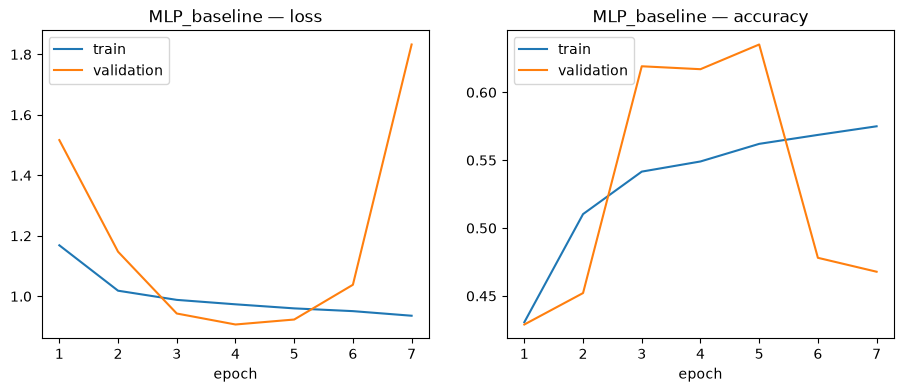

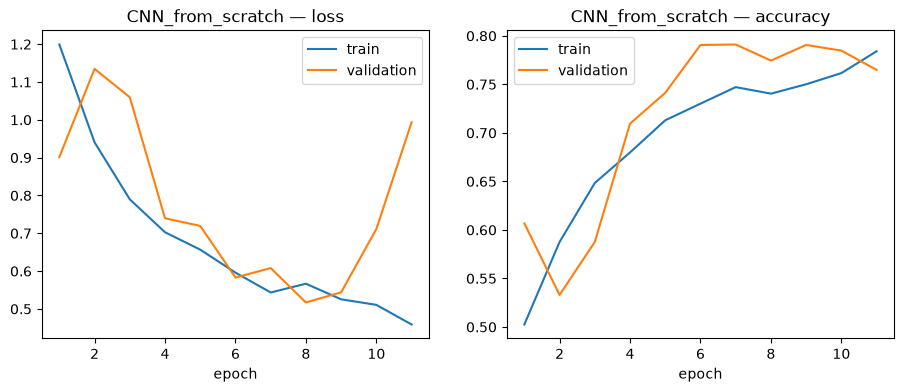

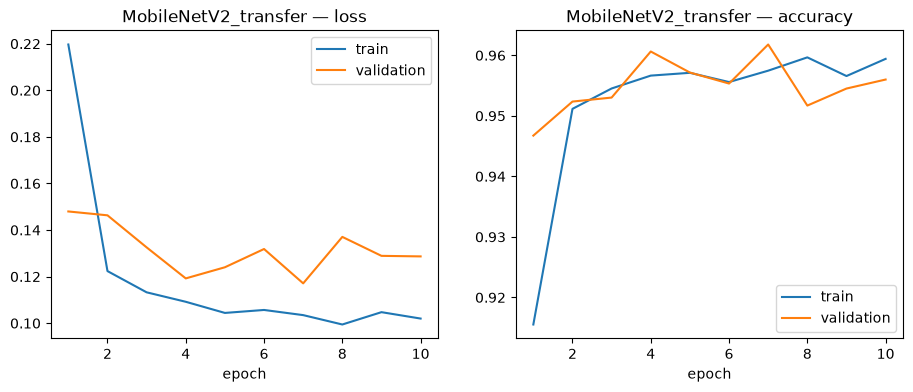

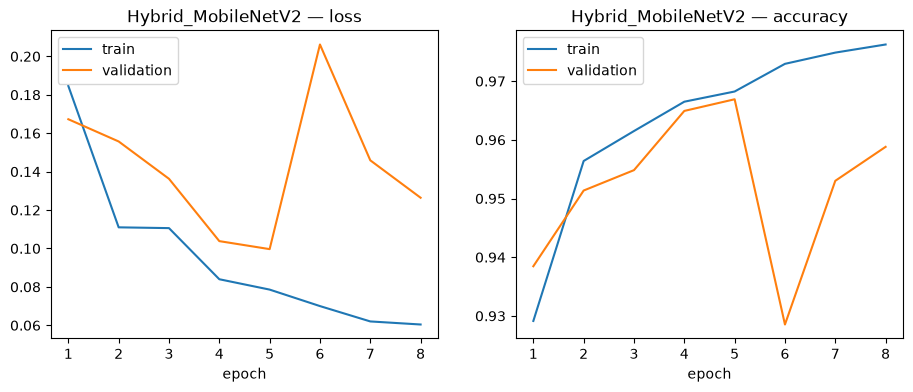

[Block 8] OK


In [ ]:
print("[Block 8] Loss / accuracy curves : starting...")

def plot_history(h, title=""):
    # Two charts side by side: the loss on the left, the accuracy on the right
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    for a, m in zip(ax, ["loss", "accuracy"]):
        epochs = h["epoch"] + 1                              # h has one row per finished epoch. We count epochs from 1
        a.plot(epochs, h[m], label="train")
        a.plot(epochs, h["val_" + m], label="validation")
        a.set_title(f"{title} — {m}")
        a.set_xlabel("epoch")
        a.legend()
    plt.show()

# One pair of charts (loss, accuracy) per model, asked by the assignment
for name, history in histories.items():
    plot_history(history, title=name)

print("[Block 8] OK")

## 9. Final Evaluation on the Test Set

Now, and only now, each model sees the **test images**: the 15 % kept aside from the start. This score
is the most honest one, because the model never learned from these images.

For each model we show:
- the **report per category**: *precision* (when the model says "Painting", how often is it right?),
  *recall* (out of all the real paintings, how many did it find?) and *F1* (a mix of the two);
- the **confusion matrix**: for each real category (row), what the model answered (column). The
  **Photo** column shows which documents the model takes for photos.

The results of all the models go into `results/deliverable1_results.csv`, one row per model. This table
also answers deliverable 1 (*photo or not?*) with `precision_photo`, `recall_photo` and `f1_photo`.

In [ ]:
print("[Block 9] Final evaluation : starting...")

import io

def fig_to_tf_image(fig):
    # Turn a matplotlib chart into an image that TensorBoard can show
    buf = io.BytesIO()
    fig.savefig(buf, format="png")    # draw the chart as a PNG image, in memory
    plt.close(fig)                    # do not show it in the notebook: it only goes to TensorBoard
    buf.seek(0)
    img = tf.image.decode_png(buf.getvalue(), channels=4)
    return tf.expand_dims(img, 0)     # TensorBoard expects a group of images, here a group of 1

def evaluate_and_log(name, model):
    print(f"  Evaluating {name}...")
    # The right answers for all the test images, always in the same order (the test set is never mixed)
    y_true = np.concatenate([y.numpy() for _, y in test_ds]).astype(int)

    t0 = time.time()
    y_prob = model.predict(test_ds, verbose=0)            # for each image, 5 probabilities (one per category)
    ms_per_img = (time.time() - t0) / len(y_true) * 1000  # time per image in milliseconds, useful for TouNum in production
    y_pred = y_prob.argmax(axis=1)                         # the answer = the category with the highest probability

    labels = list(range(NUM_CLASSES))
    # Precision, recall and F1 for each category
    report = classification_report(y_true, y_pred, labels=labels, target_names=class_names,
                                   digits=3, zero_division=0)
    print(report)

    # The test set is never mixed, so prediction number i is for row i of test_df. We check it
    assert (y_true == test_df["label"].to_numpy()).all(), "test_ds and test_df are not aligned"
    cm = confusion_matrix(y_true, y_pred, labels=labels)   # cm[row][column] = number of images of category "row" answered "column"
    # The same matrix in shares: each row adds up to 1. The diagonal is the share of each category found
    # correctly (its recall). The Photo column is the share of each category taken for a photo: this is
    # where we see WHICH documents fool the model.
    per_cat = pd.DataFrame(cm / cm.sum(axis=1, keepdims=True), index=class_names, columns=class_names).round(3)
    per_cat.index.name, per_cat.columns.name = "true", "predicted"
    print(f"  {name} - confusion matrix normalized per true category (test):")
    display(per_cat)

    fig, ax = plt.subplots(figsize=(7, 7))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, xticks_rotation=45)   # the same matrix as a picture, with counts
    ax.set_title(name)

    # Also send the matrix picture and the report to TensorBoard, in the folder of this model
    # (the picture is not shown in the notebook: the table above already shows the same thing)
    eval_writer = tf.summary.create_file_writer(str(LOGS / name / "eval"))
    with eval_writer.as_default():
        tf.summary.image("Confusion Matrix", fig_to_tf_image(fig), step=0)
        tf.summary.text("Classification Report", report, step=0)

    # Deliverable 1 question (photo or not?): we only look at "is it Photo?" in the right and predicted answers
    is_photo, pred_photo = y_true == PHOTO, y_pred == PHOTO
    row = {   # one row of the results table, for this model
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),   # share of test images that get the right category
        "f1_macro": f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),   # F1 averaged over the 5 categories, each counting the same
        "precision_photo": precision_score(is_photo, pred_photo, zero_division=0),   # when the model says "photo", how often it is right
        "recall_photo": recall_score(is_photo, pred_photo, zero_division=0),         # out of all the real photos, how many it found
        "f1_photo": f1_score(is_photo, pred_photo, zero_division=0),                 # a mix of the two above
        "ms_per_image": round(ms_per_img, 2),
        "parameters": model.count_params(),   # number of weights in the model
        "size_MB": round((RESULTS / f"{name}.keras").stat().st_size / 1e6, 1),   # size of the .keras file
        # share of each category found correctly, e.g. recall_Painting = share of test paintings answered "Painting"
        **{f"recall_{cat}": per_cat.loc[cat, cat] for cat in class_names},
    }
    # Add the row of this model to the results table (and remove its old row, if there was one)
    path = RESULTS / "deliverable1_results.csv"
    results = pd.read_csv(path) if path.exists() else pd.DataFrame()
    results = pd.concat([results[results.get("model") != name] if len(results) else results,
                         pd.DataFrame([row])], ignore_index=True)
    results.to_csv(path, index=False)
    print(f"  {name}: OK")
    return results

for name, model in models.items():
    results_df = evaluate_and_log(name, model)

print("[Block 9] OK")
results_df

[Block 9] Final evaluation : starting...
  Evaluating MLP_baseline...


Corrupt JPEG data: 419 extraneous bytes before marker 0xd9
W0000 00:00:1791379223.541294  168861 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
Corrupt JPEG data: 419 extraneous bytes before marker 0xd9
W0000 00:00:1791379225.732835  168923 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


              precision    recall  f1-score   support

    Painting      0.501     0.817     0.621      1500
       Photo      0.657     0.328     0.437      1499
  Schematics      0.601     0.522     0.559      1336
      Sketch      1.000     0.147     0.256       211
        Text      0.760     0.843     0.799      1500

    accuracy                          0.613      6046
   macro avg      0.704     0.531     0.535      6046
weighted avg      0.644     0.613     0.593      6046

  MLP_baseline - confusion matrix normalized per true category (test):


predicted,Painting,Photo,Schematics,Sketch,Text
true,,,,,
Painting,0.817,0.095,0.088,0.000,0.001
Photo,0.642,0.328,0.030,0.000,0.000
Schematics,0.191,0.085,0.522,0.000,0.201
Sketch,0.000,0.000,0.242,0.147,0.611
Text,0.000,0.000,0.157,0.000,0.843


  MLP_baseline: OK
  Evaluating CNN_from_scratch...


...

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9
W0000 00:00:1791379241.932535  169349 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
Corrupt JPEG data: 419 extraneous bytes before marker 0xd9
W0000 00:00:1791379244.922958  169396 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


              precision    recall  f1-score   support

    Painting      0.968     0.915     0.941      1500
       Photo      0.953     0.977     0.965      1499
  Schematics      0.932     0.973     0.952      1336
      Sketch      0.968     1.000     0.984       211
        Text      0.996     0.981     0.989      1500

    accuracy                          0.963      6046
   macro avg      0.963     0.969     0.966      6046
weighted avg      0.963     0.963     0.963      6046

  Hybrid_MobileNetV2 - confusion matrix normalized per true category (test):


predicted,Painting,Photo,Schematics,Sketch,Text
true,,,,,
Painting,0.915,0.045,0.040,0.000,0.000
Photo,0.018,0.977,0.005,0.000,0.000
Schematics,0.013,0.004,0.973,0.005,0.004
Sketch,0.000,0.000,0.000,1.000,0.000
Text,0.000,0.000,0.019,0.000,0.981


  Hybrid_MobileNetV2: OK
[Block 9] OK


,model,accuracy,f1_macro,precision_photo,recall_photo,f1_photo,ms_per_image,parameters,size_MB,recall_Painting,recall_Photo,recall_Schematics,recall_Sketch,recall_Text
0,MLP_baseline,0.613463,0.534573,0.657296,0.327552,0.437222,0.46,19276805,231.4,0.817,0.328,0.522,0.147,0.843
1,CNN_from_scratch,0.766953,0.764175,0.599820,0.887925,0.715976,0.50,12864837,154.4,0.366,0.888,0.798,0.962,0.992
2,MobileNetV2_transfer,0.961131,0.963411,0.945232,0.978652,0.961652,1.01,2264389,9.7,0.937,0.979,0.927,1.000,0.993
3,Hybrid_MobileNetV2,0.962785,0.966088,0.953155,0.977318,0.965086,1.12,3013957,18.7,0.915,0.977,0.973,1.000,0.981


## 10. Bias/Variance Analysis

*To be written after training the 4 models again on the 5 categories.*

The old analysis no longer applies. It was about the old version (photo or not, without the paintings,
21,979 training images), and those models came from an older split: about 70 % of today's test photos
were in their training images. They had already seen the answers, so their test scores were too high.

What to write for each model, using `results/logs/<model>_history.csv` (section 8) and
`results/deliverable1_results.csv` (section 9):
- **training vs validation curves**: a gap that keeps growing means the model learns by heart
  (overfitting); both curves bad means the model learns too little (underfitting);
- **test scores**: accuracy, macro F1, and photo precision / recall (the deliverable 1 question);
- **mix-ups**: which categories the model confuses (confusion matrix), and which ones it takes for photos.